In [11]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

In [12]:
train_data = fetch_20newsgroups(
    subset="train",
    remove=("headers","footers","quotes")
)
test_data = fetch_20newsgroups(
    subset="test",
    remove=("headers","footers","quotes")
)

In [17]:
x_train_text = train_data.data
y_train = train_data.target

x_test_text = test_data.data
y_test = test_data.target

class_names = train_data.target_names

In [18]:
print("Training Documents :",len(x_train_text))
print("Testing Documents :",len(x_test_text))
print("Number of Classes:",len(class_names))

Training Documents : 11314
Testing Documents : 7532
Number of Classes: 20


In [23]:
vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2
)
x_train= vectorizer.fit_transform(x_train_text)
x_test= vectorizer.transform(x_test_text)

In [25]:
print("Training feature matrix:",x_train.shape)
print("Testing feature matrix:",x_test.shape)

Training feature matrix: (11314, 39115)
Testing feature matrix: (7532, 39115)


In [28]:
mnb = MultinomialNB()
mnb.fit(
    x_train,
    y_train
)
y_pred_mnb = mnb.predict(x_test)

In [30]:
binary_vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)
x_train_binary= binary_vectorizer.fit_transform(x_train_text)
x_test_binary= binary_vectorizer.transform(x_test_text)

In [31]:
bnb = BernoulliNB()
bnb.fit(
    x_train_binary,
    y_train
)
y_pred_bnb = bnb.predict(
    x_test_binary
)

In [34]:
results = pd.DataFrame({
    "Model":[
        "Multinomail NB",
        "Bernoulli NB"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_mnb),
        accuracy_score(y_test,y_pred_bnb),
        ],
    "Precision":[
        precision_score(
            y_test,
            y_pred_mnb,
            average="macro"
        ),
        precision_score(
            y_test,
            y_pred_bnb,
            average="macro"
        )
        ],
    "Recall":[
        recall_score(
            y_test,
            y_pred_mnb,
            average="macro"
        ),
        recall_score(
            y_test,
            y_pred_bnb,
            average="macro"
        )
        ],
    "F1-Score":[
        f1_score(
            y_test,
            y_pred_mnb,
            average="macro"
        ),
        f1_score(
            y_test,
            y_pred_bnb,
            average="macro"
        )
    ]
})
results

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomail NB,0.651089,0.634470,0.636933,0.617859
1,Bernoulli NB,0.485130,0.616678,0.469434,0.467865


<function matplotlib.pyplot.show(close=None, block=None)>

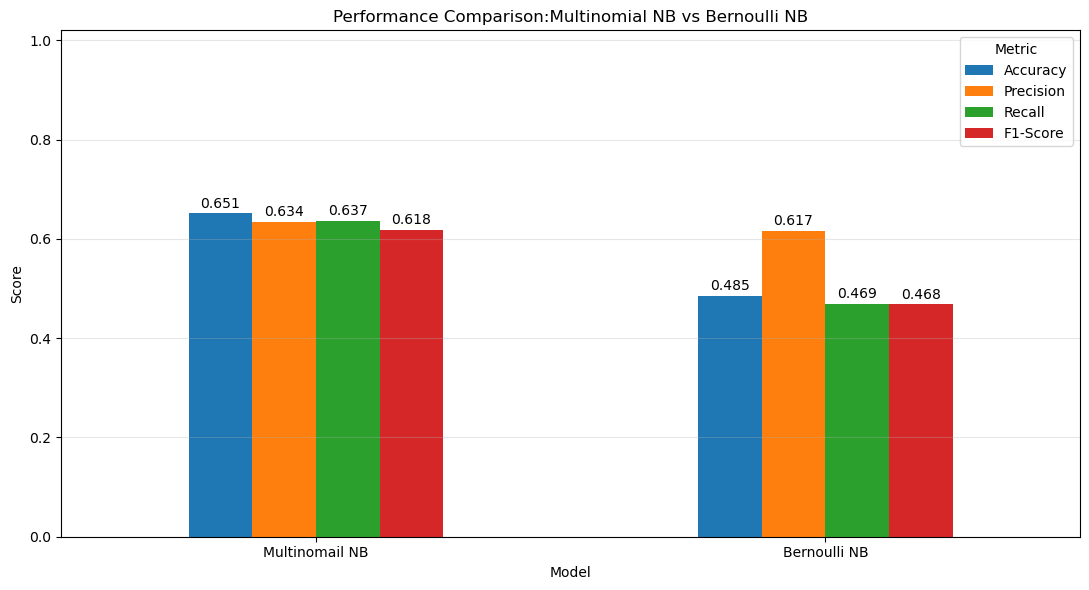

In [41]:
results_metrics=results[
    ["Model","Accuracy","Precision","Recall","F1-Score"]
]

ax= results_metrics.set_index("Model").plot(
    kind= "bar",
    figsize=(11,6)
)
plt.title(
    "Performance Comparison:Multinomial NB vs Bernoulli NB"
)
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0,1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(
    axis="y",
    alpha=0.3
)

#Display values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=2
    )
plt.tight_layout()
plt.show